# Stellar Classification — Model Training & Evaluation

**Notebook:** `03_models.ipynb`  
**Depends on:** `02_preprocessing.ipynb` (artefacts in `output/`)  
**Output:** Trained models, metrics, confusion matrices, comparison plots

---

## What this notebook does

1. Loads preprocessed train/test splits from `output/`
2. Trains **KNN** as the interpretable baseline
3. Trains **Random Forest** as the primary model
4. Evaluates both on the **full** feature set (with `redshift`)
5. Runs the core experiment: repeats RF on the **photometric-only** set (no `redshift`)
6. Compares all results side-by-side — accuracy, F1, confusion matrices
7. Saves trained models and metrics to `output/`

> **Core scientific question:** *How much accuracy does the model lose
> when `redshift` is unavailable?*

---
## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

BACKEND_DIR = Path().resolve()
DATA_PATH = BACKEND_DIR.parent / 'data' / 'star_classification.csv'
sys.path.insert(0, str(BACKEND_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

from utils.logger import setup_logger

OUTPUT_DIR = BACKEND_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

logger = setup_logger('03_models')
logger.info('Models notebook started')

CLASS_NAMES = ['STAR', 'GALAXY', 'QSO']
PALETTE = {'STAR': '#e8e8d0', 'GALAXY': '#5b9bd5', 'QSO': '#e07b39'}
print('Setup complete. Backend dir:', BACKEND_DIR)

[2026-04-20 15:56:06] [INFO] Logger initialised | script=03_models | log=run_20260420_155606_03_models.log
[2026-04-20 15:56:06] [INFO] Models notebook started


Setup complete. Backend dir: /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd


---
## 2. Load Preprocessed Data

Loading train/test splits saved by `02_preprocessing.ipynb`.
No re-processing needed.

In [2]:
# Full feature set (with redshift)
data_full = np.load(OUTPUT_DIR / 'dataset_full.npz')
X_train_full = data_full['X_train']
X_test_full  = data_full['X_test']
y_train_full = data_full['y_train']
y_test_full  = data_full['y_test']

# Photometric-only set (without redshift)
data_noz = np.load(OUTPUT_DIR / 'dataset_no_redshift.npz')
X_train_noz = data_noz['X_train']
X_test_noz  = data_noz['X_test']
y_train_noz = data_noz['y_train']
y_test_noz  = data_noz['y_test']

logger.info(f'Full set loaded: train={X_train_full.shape}, test={X_test_full.shape}')
logger.info(f'No-redshift set loaded: train={X_train_noz.shape}, test={X_test_noz.shape}')
print(f'Full set    — X_train: {X_train_full.shape}, X_test: {X_test_full.shape}')
print(f'No-redshift — X_train: {X_train_noz.shape}, X_test: {X_test_noz.shape}')

[2026-04-20 15:56:08] [INFO] Full set loaded: train=(79999, 8), test=(20000, 8)
[2026-04-20 15:56:08] [INFO] No-redshift set loaded: train=(79999, 7), test=(20000, 7)


Full set    — X_train: (79999, 8), X_test: (20000, 8)
No-redshift — X_train: (79999, 7), X_test: (20000, 7)


---
## 3. Helper Functions

Reusable utilities for evaluation and plotting.

In [3]:
def evaluate_model(model, X_test, y_test, label='Model'):
    """Returns a dict of metrics for a fitted model."""
    y_pred = model.predict(X_test)
    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred, target_names=CLASS_NAMES)
    logger.info(f'{label} — Accuracy: {acc:.4f}, F1: {f1:.4f}')
    return {'label': label, 'accuracy': acc, 'f1': f1,
            'report': report, 'y_pred': y_pred}


def plot_confusion_matrix(y_test, y_pred, title, ax):
    """Plots a normalised confusion matrix on the given axes."""
    cm = confusion_matrix(y_test, y_pred, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        linewidths=0.5, linecolor='white', ax=ax,
    )
    ax.set_title(title, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

---
## 4. KNN — Baseline Model

KNN (k-Nearest Neighbours) is our interpretable baseline.
It classifies each object by the majority class among its *k* nearest
neighbours in feature space — no learning, pure geometry.

We use **k=10** with the full feature set only.
KNN on 80k rows is already slow; photometric-only comparison
is reserved for Random Forest (the primary model).

In [4]:
logger.info('Training KNN (k=10) on full feature set...')
print('Training KNN... (this may take ~1-2 min on 80k rows)')

knn = KNeighborsClassifier(n_neighbors=10, n_jobs=-1)
knn.fit(X_train_full, y_train_full)

logger.info('KNN training complete')
print('KNN training complete.')

[2026-04-20 15:56:18] [INFO] Training KNN (k=10) on full feature set...
[2026-04-20 15:56:18] [INFO] KNN training complete


Training KNN... (this may take ~1-2 min on 80k rows)
KNN training complete.


In [7]:
knn_results = evaluate_model(knn, X_test_full, y_test_full, label='KNN (full)')

print(f"\nKNN Accuracy : {knn_results['accuracy']:.4f}")
print(f"KNN F1 Score : {knn_results['f1']:.4f}")
print(f"\nClassification Report:\n{knn_results['report']}")

[2026-04-20 16:07:39] [INFO] KNN (full) — Accuracy: 0.9382, F1: 0.9383



KNN Accuracy : 0.9382
KNN F1 Score : 0.9383

Classification Report:
              precision    recall  f1-score   support

        STAR       0.89      0.92      0.91      4319
      GALAXY       0.95      0.95      0.95     11889
         QSO       0.97      0.91      0.94      3792

    accuracy                           0.94     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.94      0.94      0.94     20000



In [8]:
joblib.dump(knn, OUTPUT_DIR / 'model_knn.joblib')
logger.info('KNN model saved to output/')
print('KNN saved to output/model_knn.joblib')

[2026-04-20 16:07:40] [INFO] KNN model saved to output/


KNN saved to output/model_knn.joblib


---
## 5. Random Forest — Primary Model

Random Forest is our primary model. It builds an ensemble of decision trees,
each trained on a random subset of data and features.
The final prediction is the majority vote across all trees.

Key advantages over KNN for this task:
- Handles the photometric bands' skewed distributions well
- Natively provides **feature importances**
- Scales better to 100k rows
- Results are directly interpretable in the context of astrophysics

We train on **both feature sets** to enable the core experiment.

In [19]:
RF_PARAMS = dict(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

# ── WITH redshift ─────────────────────────────────────────────────────────
logger.info('Training Random Forest (full features)...')
print('Training RF — full features (with redshift)...')

rf_full = RandomForestClassifier(**RF_PARAMS)
rf_full.fit(X_train_full, y_train_full)

logger.info('RF (full) training complete')
print('Done.')

[2026-04-20 16:39:12] [INFO] Training Random Forest (full features)...


Training RF — full features (with redshift)...


[2026-04-20 16:39:18] [INFO] RF (full) training complete


Done.


In [10]:
# ── WITHOUT redshift ──────────────────────────────────────────────────────
logger.info('Training Random Forest (no redshift)...')
print('Training RF — photometric only (no redshift)...')

rf_noz = RandomForestClassifier(**RF_PARAMS)
rf_noz.fit(X_train_noz, y_train_noz)

logger.info('RF (no redshift) training complete')
print('Done.')

[2026-04-20 16:08:04] [INFO] Training Random Forest (no redshift)...


Training RF — photometric only (no redshift)...


[2026-04-20 16:08:09] [INFO] RF (no redshift) training complete


Done.


In [11]:
rf_full_results = evaluate_model(rf_full, X_test_full, y_test_full, label='RF (full)')
rf_noz_results  = evaluate_model(rf_noz,  X_test_noz,  y_test_noz,  label='RF (no redshift)')

print(f"\nRF (full)          Accuracy: {rf_full_results['accuracy']:.4f}   F1: {rf_full_results['f1']:.4f}")
print(f"RF (no redshift)   Accuracy: {rf_noz_results['accuracy']:.4f}   F1: {rf_noz_results['f1']:.4f}")
print(f"\nAccuracy drop without redshift: {(rf_full_results['accuracy'] - rf_noz_results['accuracy'])*100:.2f} pp")

[2026-04-20 16:09:31] [INFO] RF (full) — Accuracy: 0.9778, F1: 0.9777
[2026-04-20 16:09:31] [INFO] RF (no redshift) — Accuracy: 0.8787, F1: 0.8779



RF (full)          Accuracy: 0.9778   F1: 0.9777
RF (no redshift)   Accuracy: 0.8787   F1: 0.8779

Accuracy drop without redshift: 9.90 pp


In [12]:
joblib.dump(rf_full, OUTPUT_DIR / 'model_rf_full.joblib')
joblib.dump(rf_noz,  OUTPUT_DIR / 'model_rf_no_redshift.joblib')
logger.info('RF models saved to output/')
print('RF models saved.')

[2026-04-20 16:09:35] [INFO] RF models saved to output/


RF models saved.


---
## 6. Confusion Matrices

Normalised confusion matrices (row = true class, column = predicted class).
Values show the fraction of each true class predicted as each other class.

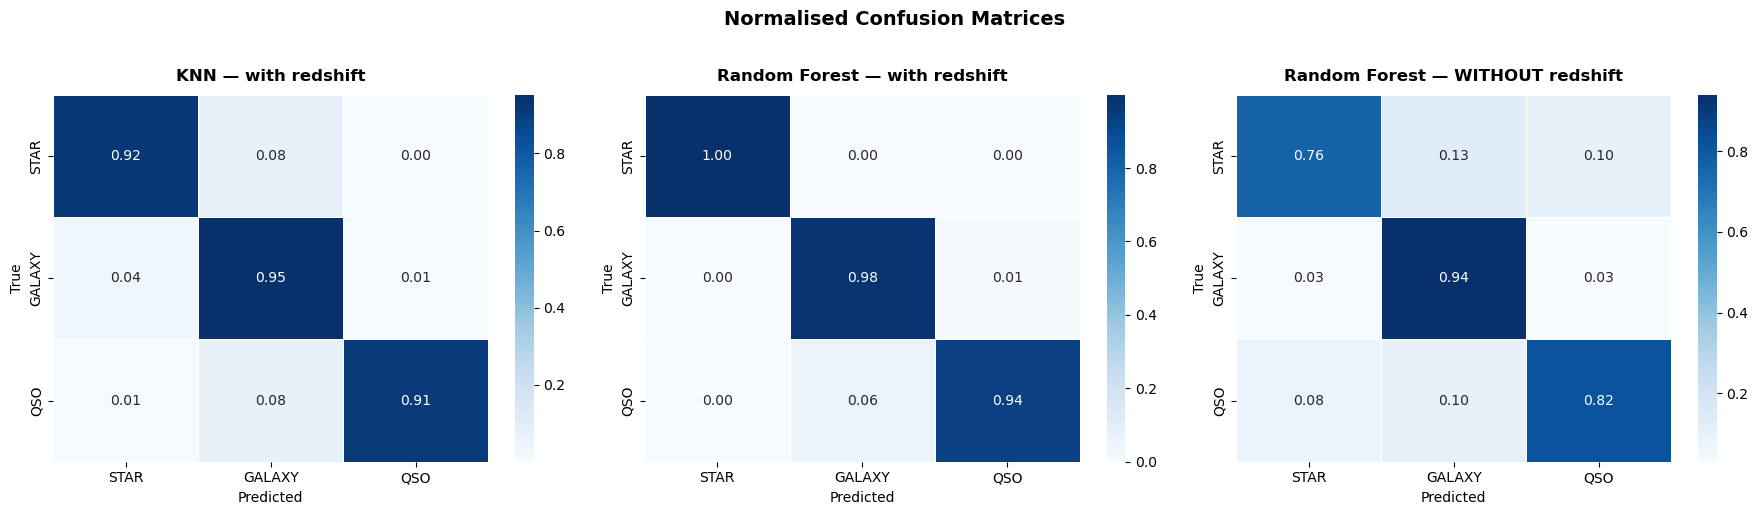

[2026-04-20 16:17:31] [INFO] Confusion matrices saved


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_confusion_matrix(y_test_full, knn_results['y_pred'],
                      'KNN — with redshift', axes[0])

plot_confusion_matrix(y_test_full, rf_full_results['y_pred'],
                      'Random Forest — with redshift', axes[1])

plot_confusion_matrix(y_test_noz, rf_noz_results['y_pred'],
                      'Random Forest — WITHOUT redshift', axes[2])

plt.suptitle('Normalised Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'models_01_confusion_matrices.png', bbox_inches='tight')
plt.show()
logger.info('Confusion matrices saved')

---
## 7. Model Comparison

Side-by-side accuracy and F1 comparison across all three configurations.

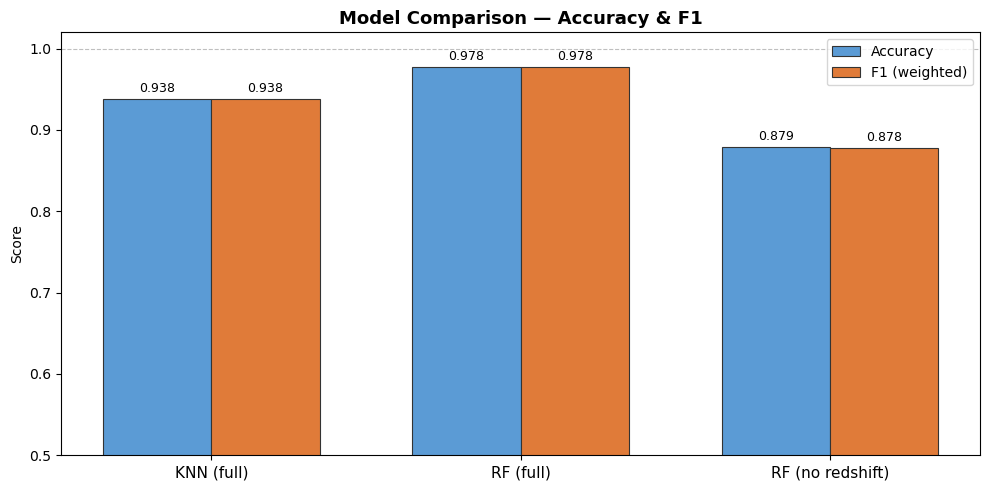

[2026-04-20 16:17:35] [INFO] Comparison plot saved


In [14]:
results = [knn_results, rf_full_results, rf_noz_results]
labels   = [r['label'] for r in results]
accs     = [r['accuracy'] for r in results]
f1s      = [r['f1'] for r in results]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy',
               color='#5b9bd5', edgecolor='#333', linewidth=0.8)
bars2 = ax.bar(x + width/2, f1s,  width, label='F1 (weighted)',
               color='#e07b39', edgecolor='#333', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylim(0.5, 1.02)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & F1', fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'models_02_comparison.png', bbox_inches='tight')
plt.show()
logger.info('Comparison plot saved')

---
## 8. Full Classification Reports

Per-class precision, recall and F1 for each model configuration.

In [15]:
for r in results:
    print(f"{'='*55}")
    print(f"  {r['label']}")
    print(f"{'='*55}")
    print(r['report'])
    print()

  KNN (full)
              precision    recall  f1-score   support

        STAR       0.89      0.92      0.91      4319
      GALAXY       0.95      0.95      0.95     11889
         QSO       0.97      0.91      0.94      3792

    accuracy                           0.94     20000
   macro avg       0.93      0.93      0.93     20000
weighted avg       0.94      0.94      0.94     20000


  RF (full)
              precision    recall  f1-score   support

        STAR       0.99      1.00      0.99      4319
      GALAXY       0.98      0.98      0.98     11889
         QSO       0.96      0.94      0.95      3792

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000


  RF (no redshift)
              precision    recall  f1-score   support

        STAR       0.83      0.76      0.80      4319
      GALAXY       0.92      0.94      0.93     11889
         QSO       0.79      

---
## 9. Save Metrics

Persist all numeric results to `output/metrics.json`.
The feature importance notebook and the frontend will read from here.

In [16]:
metrics = {
    r['label']: {
        'accuracy': round(r['accuracy'], 6),
        'f1_weighted': round(r['f1'], 6),
    }
    for r in results
}

with open(OUTPUT_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

logger.info(f'Metrics saved: {metrics}')
print('Metrics saved to output/metrics.json')
print(json.dumps(metrics, indent=2))

[2026-04-20 16:22:39] [INFO] Metrics saved: {'KNN (full)': {'accuracy': 0.9382, 'f1_weighted': 0.938327}, 'RF (full)': {'accuracy': 0.97775, 'f1_weighted': 0.977673}, 'RF (no redshift)': {'accuracy': 0.8787, 'f1_weighted': 0.877893}}


Metrics saved to output/metrics.json
{
  "KNN (full)": {
    "accuracy": 0.9382,
    "f1_weighted": 0.938327
  },
  "RF (full)": {
    "accuracy": 0.97775,
    "f1_weighted": 0.977673
  },
  "RF (no redshift)": {
    "accuracy": 0.8787,
    "f1_weighted": 0.877893
  }
}


In [20]:
# Сохранить текстовые отчёты по каждой модели в .txt

for r in results:
    label_sanitized = (
        r['label']
        .lower()
        .replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
    )
    path = OUTPUT_DIR / f'report_{label_sanitized}.txt'
    with open(path, 'w') as f:
        f.write(r['report'])
    print('Saved:', path)

    import joblib
joblib.dump(rf_full, OUTPUT_DIR / 'rf_full.pkl')
joblib.dump(rf_noz,  OUTPUT_DIR / 'rf_noz.pkl')
print('Models saved!')



Saved: /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/report_knn_full.txt
Saved: /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/report_rf_full.txt
Saved: /Users/nikitadackov/PycharmProjects/JupyterProject/BackEnd/output/report_rf_no_redshift.txt
Models saved!


---
## 10. Summary

### Models trained
| Model | Features | Notes |
|-------|----------|-------|
| KNN (k=10) | Full (with redshift) | Geometric baseline |
| Random Forest (200 trees) | Full (with redshift) | Primary model |
| Random Forest (200 trees) | Photometric-only | Redshift experiment |

### Key finding
The accuracy gap between **RF with redshift** and **RF without redshift**
quantifies exactly how much spectroscopic information the model relies on.
This number is the central result of the project.

### What's next
`04_feature_importance.ipynb` — analyse which features drive predictions,
visualise feature importances per class, and interpret results
in the context of astrophysics.